In [1]:
import pandas as pd
import itertools
import json
import glob
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

In [2]:
def _extract_fn(f):
    return f[len('DESeq2results_'):-len('.csv')]

# https://stackoverflow.com/questions/31123268/finding-intersect-values-using-python-matplotlib-venn
def get_venn_sections(sets):
    """
    Given a list of sets, return a new list of sets with all the possible
    mutually exclusive overlapping combinations of those sets.  Another way
    to think of this is the mutually exclusive sections of a venn diagram
    of the sets.  If the original list has N sets, the returned list will
    have (2**N)-1 sets.

    Parameters
    ----------
    sets : list of set

    Returns
    -------
    combinations : list of tuple
        tag : str
            Binary string representing which sets are included / excluded in
            the combination.
        set : set
            The set formed by the overlapping input sets.
    """
    num_combinations = 2 ** len(sets)
    bit_flags = [2 ** n for n in range(len(sets))]
    flags_zip_sets = [z for z in zip(bit_flags, sets)]

    combo_sets = []
    for bits in range(num_combinations - 1, 0, -1):
        include_sets = [s for flag, s in flags_zip_sets if bits & flag]
        exclude_sets = [s for flag, s in flags_zip_sets if not bits & flag]
        combo = set.intersection(*include_sets)
        combo = set.difference(combo, *exclude_sets)
        tag = ''.join([str(int((bits & flag) > 0)) for flag in bit_flags])
        combo_sets.append((tag, list(combo)))
    return combo_sets

In [3]:
groups = {
    'EXP': [
        'DESeq2results_delta-EXP_vs_WT-EXP.csv',
        'DESeq2results_delta_omega-EXP_vs_delta-EXP.csv',
        'DESeq2results_delta_omega-EXP_vs_WT-EXP.csv',
    ],
     'STA': [
        'DESeq2results_delta_omega-STAT_vs_delta-STAT.csv',
        'DESeq2results_delta_omega-STAT_vs_WT-STAT.csv',
        'DESeq2results_delta-STAT_vs_WT-STAT.csv',
    ]
}
 

In [4]:
lfc_cutoff = 2
padj_cutoff = 0.05
data = {
    'UP': {'EXP': [], 'STA': []},
    'DOWN': {'EXP': [], 'STA': []}
}
for k, v in groups.items():
    for f in v:
        d = pd.read_csv(f'../DESeq_all/{f}', sep=',')
        d.rename(columns={'Unnamed: 0': 'locus_id'}, inplace=True)
        data['UP'][k].append((_extract_fn(f), d.loc[(d.log2FoldChange>=lfc_cutoff) & (d.padj < padj_cutoff),:]))
        data['DOWN'][k].append((_extract_fn(f), d.loc[(d.log2FoldChange<=(-1*lfc_cutoff)) & (d.padj < padj_cutoff),:]))

In [5]:
colors = {
    'delta-EXP_vs_WT-EXP': 'red',
    'delta_omega-EXP_vs_delta-EXP': 'green',
    'delta_omega-EXP_vs_WT-EXP': 'blue',
    'delta-STAT_vs_WT-STAT': 'red',
    'delta_omega-STAT_vs_delta-STAT': 'green',
    'delta_omega-STAT_vs_WT-STAT': 'blue',
}

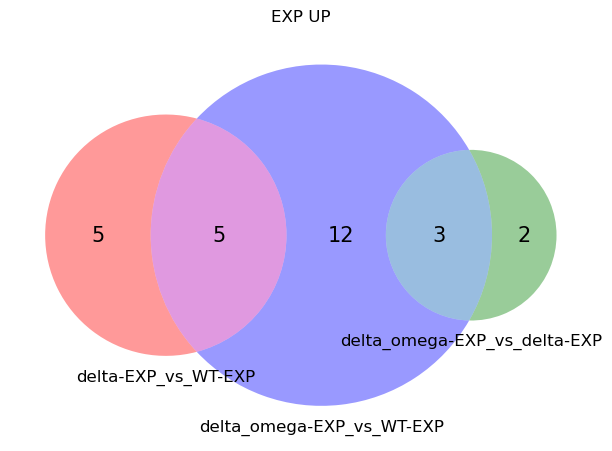

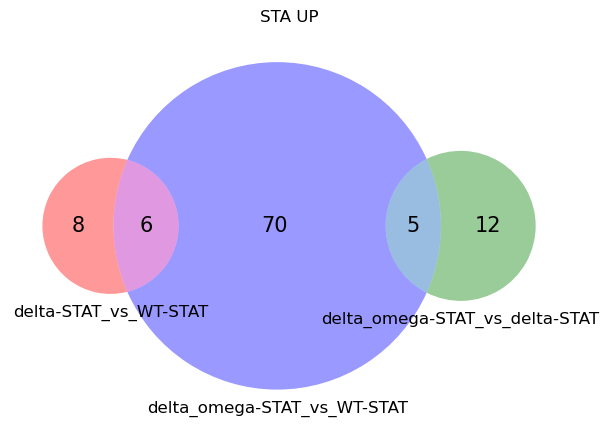

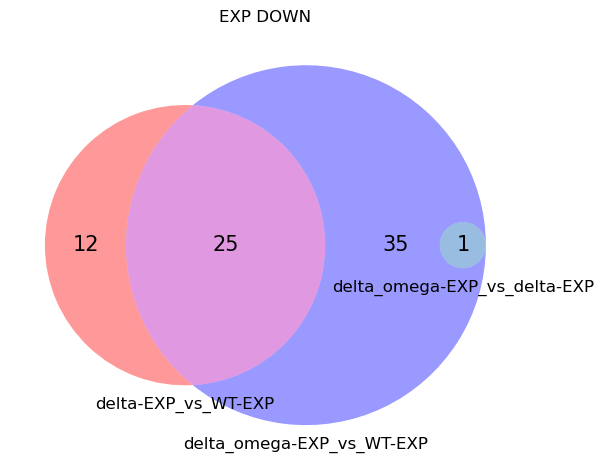

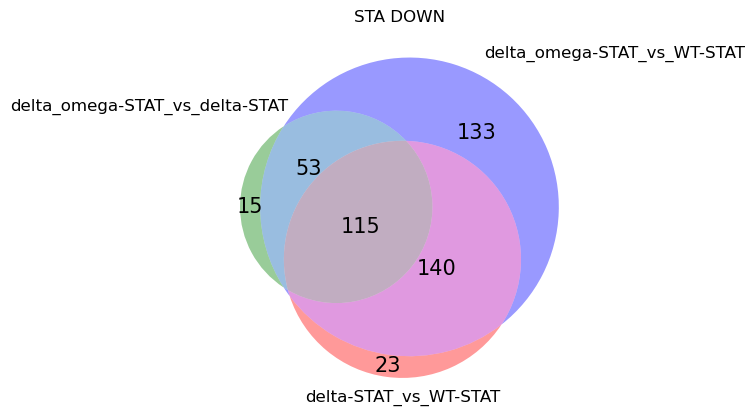

In [8]:
for gr, kk in itertools.product(['UP', 'DOWN'], ['EXP', 'STA']):
    a = venn3(
        [set(d[1].locus_id) for d in data[gr][kk]], 
        [d[0] for d in data[gr][kk]],
        set_colors=[colors[d[0]] for d in data[gr][kk]]
    )
    plt.title(f'{kk} {gr}')
    plt.tight_layout()
    
    for x in range(len(a.subset_labels)):
        if a.subset_labels[x] is not None:
            a.subset_labels[x].set_fontsize(15)
            
    plt.savefig(f'{kk}-{gr}.svg')
    plt.show()
    
    items = get_venn_sections([set(d[1].locus_id) for d in data[gr][kk]])
    with open(f'{gr}-{kk}.txt', 'w') as f:
        f.write('order:' + ' '.join([d[0] for d in data[gr][kk]]) + '\n')
        f.write(''.join(f'{k}: {v}\n' for k, v in items))

    
    df = pd.DataFrame(items, columns=['groups', 'genes'])
    df['c'] = df.genes.apply(len)
    df['p'] = df.c / df.c.sum() * 100
    df['rp'] = df.p.apply(round)
    df['total_check'] = df.rp.sum()
    df['order'] = ' '.join([d[0] for d in data[gr][kk]])
    df.to_excel(f'{gr}-{kk}_percent.xlsx')
    
    #b = pd.DataFrame(items)
    #b = b.rename(columns={0: ' '.join([d[0] for d in data[gr][kk]])})
    #b.to_excel(f'{gr}-{kk}.xlsx')